# Predicting Polarity in Political News Through Machine Learning Models: Logistic Regression and BERT



#### Upload libraries/packages

In [404]:
import json
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics
import re


import torch
import random
import numpy as np
from torch import nn
from tqdm import tqdm
from torch.optim import Adam
from sklearn.metrics import f1_score, classification_report
from transformers import BertTokenizer, BertModel


import torch
import random
import numpy as np
import pandas as pd
from torch import nn
from tqdm import tqdm
from pprint import pprint
from torch.optim import Adam
from sklearn.metrics import f1_score
from sklearn.datasets import load_files
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split

#### Download Dataset

https://github.com/fhamborg/NewsMTSC/raw/main/NewsSentiment/controller_data/datasets/NewsMTSC-dataset/NewsMTSC-dataset.zip


In [405]:
from pathlib import Path

train_path = Path.home() / "Downloads" / "NewsMTSC-dataset" / "train.jsonl"
dev_test_mt = Path.home() / "Downloads" / "NewsMTSC-dataset" / "devtest_mt.jsonl"
dev_test_rw = Path.home() / "Downloads" / "NewsMTSC-dataset" / "devtest_rw.jsonl"



#### Finding lengths

In [406]:
with open(train_path, "r") as f:
    training_data = [json.loads(line) for line in f]
print(f"Length of training data: {len(training_data)}")

with open(dev_test_mt, "r") as f:
    test_data1 = [json.loads(line) for line in f]
print(f"Length of training data: {len(test_data1)}")

with open(dev_test_rw, "r") as f:
    test_data2 = [json.loads(line) for line in f]
print(f"Length of training data: {len(test_data2)}")


Length of training data: 7758
Length of training data: 721
Length of training data: 1067


#### First 10 lines of training data

In [408]:
for line in range(10):
    print(training_data[line])


{'primary_gid': 'allsides_1000_401_25_Reality Leigh Winner_0_6', 'sentence_normalized': 'Winner wrote that she had a 30-minute private meeting with the Republican lawmaker’s state policy director.', 'targets': [{'Input.gid': 'allsides_1000_401_25_Reality Leigh Winner_0_6', 'from': 0, 'to': 6, 'mention': 'Winner', 'polarity': 4.0}]}
{'primary_gid': 'allsides_1000_401_3_Reality Leigh Winner_0_3', 'sentence_normalized': 'She also recently referred to President Trump as a “piece of shit” because of his position on the Dakota Access Pipeline (DAPL) protests.', 'targets': [{'Input.gid': 'allsides_1000_401_3_Reality Leigh Winner_0_3', 'from': 0, 'to': 3, 'mention': 'She', 'polarity': 2.0}, {'Input.gid': 'allsides_1000_401_3_’ Trump_30_45', 'from': 30, 'to': 45, 'mention': 'President Trump', 'polarity': 2.0}]}
{'primary_gid': 'allsides_1018_408_1_Hillary Clinton_2_17', 'sentence_normalized': 'Hillary Clinton blamed the Democratic National Committee, Facebook, and conspiracy site Infowars Wedne

#### Cleaning and extracting features: sentence_normalized and polarity

In [409]:
sentences = []
polarities = []

for line in training_data:
    sentence = line["sentence_normalized"]
    clean = sentence.lower()
    sentences.append(clean)
    targets = line["targets"]
    polarity = targets[0]["polarity"]
    polarities.append(polarity)

print(sentences[:10])
print(polarities[:10])

for i in range(len(polarities)):
    if polarities[i] == 2:
        polarities[i] = 0
    if polarities[i] == 4:
        polarities[i] = 1
    if polarities[i] == 6:
        polarities[i] = 2

print(polarities[:10])


['winner wrote that she had a 30-minute private meeting with the republican lawmaker’s state policy director.', 'she also recently referred to president trump as a “piece of shit” because of his position on the dakota access pipeline (dapl) protests.', 'hillary clinton blamed the democratic national committee, facebook, and conspiracy site infowars wednesday for her election defeat during an interview in which she pointed at a total of 18 alleged\xa0guilty parties for her big loss.', '(related:\xa0the 44 most damning stories from wikileaks) during the same event, clinton also\xa0attacked\xa0facebook, twitter bots, the new york times, steve bannon, and the media in general.', 'hillary clinton takes "responsibility" for loss, but says others contributed', 'clinton also looked to social media, saying sites like facebook and twitter have been "victimized by deliberate efforts to shape the conversation and push it towards conspiracies, lies, false information."', "trump's\xa0unhinged twitte

#### Visual representation of data distribution

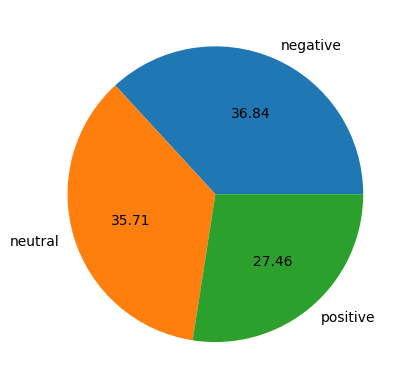

In [410]:
negative_count = polarities.count(0.0)
neutral_count = polarities.count(1.0)
positive_count = polarities.count(2.0)


y = np.array([negative_count, neutral_count, positive_count])
plt.pie(y, autopct='%1.2f', labels=["negative", "neutral", "positive"])
plt.show() 

#### Defining Variables

In [411]:
docs_train, docs_temp, y_train, y_temp = train_test_split(sentences, polarities, test_size=0.20, random_state=42)

docs_dev, docs_test, y_dev, y_test = train_test_split(docs_temp, y_temp, test_size=0.50, random_state=42)

vectorizer = TfidfVectorizer(stop_words='english')

X_train = vectorizer.fit_transform(docs_train) 


X_dev = vectorizer.transform(docs_dev)
X_test = vectorizer.transform(docs_test)


#### Baseline

Majority Class Baseline Accuracy: 0.3660

Baseline Classification Report:
               precision    recall  f1-score   support

           0       0.37      1.00      0.54       284
           1       0.00      0.00      0.00       274
           2       0.00      0.00      0.00       218

    accuracy                           0.37       776
   macro avg       0.12      0.33      0.18       776
weighted avg       0.13      0.37      0.20       776



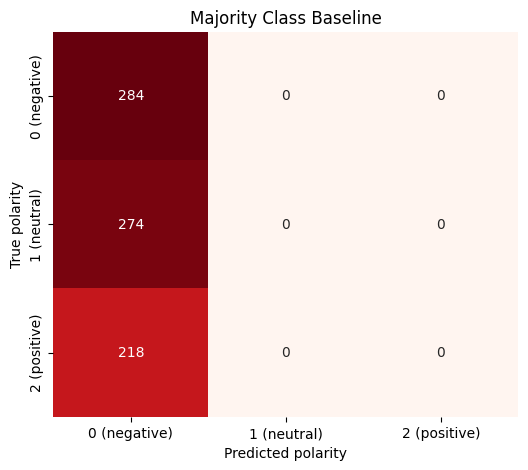

In [412]:
from sklearn.dummy import DummyClassifier
from sklearn import metrics

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_hat_baseline = baseline.predict(X_test)

baseline_accuracy = metrics.accuracy_score(y_test, y_hat_baseline)

print(f"Majority Class Baseline Accuracy: {baseline_accuracy:.4f}")
print("\nBaseline Classification Report:\n", metrics.classification_report(y_test, y_hat_baseline, zero_division=0))

confusion_matrix_baseline = confusion_matrix(y_test, y_hat_baseline)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix_baseline, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['0 (negative)', '1 (neutral)', '2 (positive)'], 
            yticklabels=['0 (negative)', '1 (neutral)', '2 (positive)'])

plt.xlabel("Predicted polarity")
plt.ylabel("True polarity")
plt.title("Majority Class Baseline")
plt.show()

#### Logistic Regression


lr_model accuracy is :  0.5412371134020618
classification report:
               precision    recall  f1-score   support

           0       0.59      0.65      0.62       284
           1       0.48      0.53      0.50       274
           2       0.57      0.40      0.47       218

    accuracy                           0.54       776
   macro avg       0.55      0.53      0.53       776
weighted avg       0.54      0.54      0.54       776



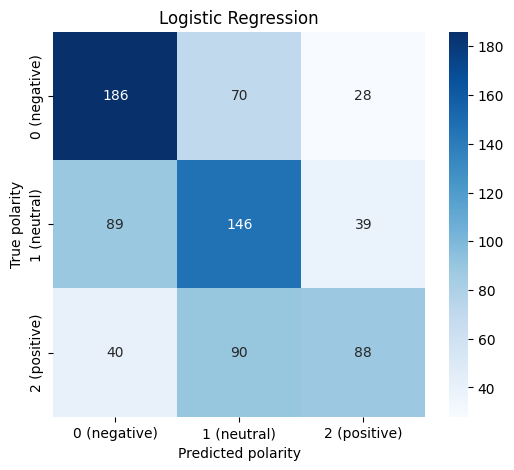

In [413]:
lr_model = LogisticRegression(random_state=3, solver='liblinear')
lr_model.fit(X_train, y_train)


y_hat_lr = lr_model.predict(X_test)

print("lr_model accuracy is : ", metrics.accuracy_score(y_test, y_hat_lr))
print("classification report:\n", metrics.classification_report(y_test, y_hat_lr))

confusion_matrix_lr = confusion_matrix(y_test, y_hat_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix_lr, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['0 (negative)', '1 (neutral)', '2 (positive)'], 
            yticklabels=['0 (negative)', '1 (neutral)', '2 (positive)'])

plt.xlabel("Predicted polarity")
plt.ylabel("True polarity")
plt.title("Logistic Regression")
plt.show()

##### Finding Keywords for logistic regression

In [414]:
import pandas as pd
import numpy as np

feature_names = vectorizer.get_feature_names_out()
polarities_labels = lr_model.classes_.astype(int).tolist()

positive_keywords = []
negative_keywords = []
neutral_keywords = []

for polarity in range(len(polarities_labels)):
    coefficients = lr_model.coef_[polarity]
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    keywords = feature_importance.sort_values(by='Coefficient', ascending=False).head(20)['Feature'].tolist()

    for word in keywords:
        if polarity == 0:
            negative_keywords.append(word)
        elif polarity == 1:
            neutral_keywords.append(word)
        elif polarity == 2:
            positive_keywords.append(word)


print("Negative keywords:", negative_keywords)
print("Neutral keywords:", neutral_keywords)
print("Positive keywords:", positive_keywords)

Negative keywords: ['accused', 'guilty', 'trump', 'allegations', 'criticism', 'claims', 'arrested', 'resignation', 'charges', 'flynn', 'pelosi', 'alleged', 'saying', 'failing', 'anti', 'comey', 'attacks', 'sexual', 'lost', 'behavior']
Neutral keywords: ['said', 'told', 'asked', 'added', 'npr', 'wrote', 'mueller', 'talks', 'says', 'chairman', 'snowden', 'thought', 'want', '2018', 'monday', 'official', 'summit', 'continue', 'left', 'killed']
Positive keywords: ['support', 'work', 'right', 'working', 'great', 'good', 'proud', 'service', 'america', 'better', 'victory', 'help', 'loved', 'praised', 'life', 'strong', 'children', 'confident', 'focused', 'family']


#### BERT

In [ ]:
def set_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

class Dataset(torch.utils.data.Dataset):
    def __init__(self, docs, ys):

        self.labels = ys
        self.texts = [tokenizer(text, padding='max_length', max_length=512, 
                                truncation=True, return_tensors="pt") for text in docs]

    def __len__(self):
        return len(self.labels)

    def get_batch_labels(self, idx):
        # Fetch a batch of labels
        return np.array(self.labels[idx])

    def get_batch_texts(self, idx):
        # Fetch a batch of inputs
        return self.texts[idx]


    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]


use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")


class BertClassifier(nn.Module):
    def __init__(self, dropout=0.2, freeze_layer_count=2):
        super(BertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        if freeze_layer_count:

            for param in self.bert.embeddings.parameters():
                param.requires_grad = False

            if freeze_layer_count != -1:
                for layer in self.bert.encoder.layer[:freeze_layer_count]:
                    for param in layer.parameters():
                        param.requires_grad = False

        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(768, 3)

    def forward(self, input_id, mask):

        _, pooled_output = self.bert(input_ids=input_id, attention_mask=mask, return_dict=False)
        dropout_output = self.dropout(pooled_output)
        linear_output = self.linear(dropout_output)
        return linear_output
    
def evaluate(model, eval_dataloader):
    total_acc = 0
    total_loss = 0

    criterion = nn.CrossEntropyLoss()

    eval_labels, eval_preds = [], []
    with torch.no_grad():
        for eval_input, eval_label in eval_dataloader:
            eval_label = eval_label.type(torch.LongTensor).to(device)
            input_ids = eval_input['input_ids'].squeeze(1).to(device)
            attention_mask = eval_input['attention_mask'].squeeze(1).to(device)

            output = model(input_ids, attention_mask)

            batch_loss = criterion(output, eval_label)
            total_loss += batch_loss.item()

            acc = (output.argmax(dim=1) == eval_label).sum().item()
            total_acc += acc

            eval_labels.extend(eval_label.tolist())
            eval_preds.extend(output.argmax(dim=1).tolist())

        f1_macro = f1_score(y_true=eval_labels, y_pred=eval_preds, average='macro')
        report = classification_report(y_true=eval_labels, y_pred=eval_preds)

    return total_acc, total_loss, f1_macro, report, eval_labels, eval_preds

def train_bert(model,
               train_docs, train_ys,
               val_docs, val_ys,
               test_docs, test_ys,
               learning_rate=2e-5, epochs=1, batch_size=16):

    print("Start training...")
    print ("==============")
    print(f"{'Epoch':^7} | {'Val Acc':^9} | {'Val F1':^9}")
    print("-"*30)

    train, val, test = Dataset(train_docs, train_ys), Dataset(val_docs, val_ys), Dataset(test_docs, test_ys)

    train_dataloader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, worker_init_fn=np.random.seed(0))
    val_dataloader = torch.utils.data.DataLoader(val, batch_size=batch_size, shuffle=True, worker_init_fn=np.random.seed(0))
    test_dataloader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle=True, worker_init_fn=np.random.seed(0))

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr = learning_rate)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    if use_cuda:
        model = model.cuda()
        criterion = criterion.cuda()

    for epoch_num in range(epochs):
        for train_input, train_label in tqdm(train_dataloader, leave=False):
            train_label = train_label.type(torch.LongTensor).to(device)
            input_ids = train_input['input_ids'].squeeze(1).to(device)
            attention_masks = train_input['attention_mask'].squeeze(1).to(device)

            model.train()
            output = model(input_ids, attention_masks)

            batch_loss = criterion(output, train_label)

            model.zero_grad()
            batch_loss.backward()
            optimizer.step()

        model.eval()
        val_acc, val_loss, val_f1, val_report, _, _ = evaluate(model, val_dataloader)
        print (f"{epoch_num + 1:^7} | {val_acc / len(val_docs):^9.3f} | {val_f1:^9.3f}")

        scheduler.step()

    val_acc, val_loss, val_f1, val_report, _, _ = evaluate(model, val_dataloader)
    test_acc, test_loss, test_f1, test_report, _, _ = evaluate(model, test_dataloader)
    print (f"Test Accuracy: {test_acc / len(test_docs):.3f}; Test F1: {test_f1:.3f}")
    print ("\n")
    print (test_report)

    return model

In [416]:
set_seed(3)
pretrained_model = BertClassifier()
if use_cuda:
    pretrained_model = pretrained_model.cuda()

test = Dataset(docs_test, y_test)
test_dataloader = torch.utils.data.DataLoader(test, batch_size=16, shuffle=False, worker_init_fn=np.random.seed(0))
test_acc, test_loss, test_f1, test_report, _, _ = evaluate(pretrained_model, test_dataloader)
print("classification report:\n", test_report)

classification report:
               precision    recall  f1-score   support

           0       0.24      0.05      0.09       284
           1       0.37      0.54      0.44       274
           2       0.28      0.41      0.33       218

    accuracy                           0.32       776
   macro avg       0.30      0.33      0.29       776
weighted avg       0.30      0.32      0.28       776



In [ ]:
set_seed(3)
finetuned_model = BertClassifier(freeze_layer_count=2) # Freeze bert layers

print ("\n")
print ("Layers being trained:")
print ("======================")
for layer, param in finetuned_model.named_parameters():
    if param.requires_grad == True:
        print(layer)

print ("\n")

train_bert(
    finetuned_model,
    docs_train, y_train,
    docs_dev, y_dev,
    docs_test, y_test,
    epochs=3
)



Layers being trained:
bert.encoder.layer.2.attention.self.query.weight
bert.encoder.layer.2.attention.self.query.bias
bert.encoder.layer.2.attention.self.key.weight
bert.encoder.layer.2.attention.self.key.bias
bert.encoder.layer.2.attention.self.value.weight
bert.encoder.layer.2.attention.self.value.bias
bert.encoder.layer.2.attention.output.dense.weight
bert.encoder.layer.2.attention.output.dense.bias
bert.encoder.layer.2.attention.output.LayerNorm.weight
bert.encoder.layer.2.attention.output.LayerNorm.bias
bert.encoder.layer.2.intermediate.dense.weight
bert.encoder.layer.2.intermediate.dense.bias
bert.encoder.layer.2.output.dense.weight
bert.encoder.layer.2.output.dense.bias
bert.encoder.layer.2.output.LayerNorm.weight
bert.encoder.layer.2.output.LayerNorm.bias
bert.encoder.layer.3.attention.self.query.weight
bert.encoder.layer.3.attention.self.query.bias
bert.encoder.layer.3.attention.self.key.weight
bert.encoder.layer.3.attention.self.key.bias
bert.encoder.layer.3.attention.self.

 20%|██        | 78/388 [11:50<44:12,  8.56s/it]  

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.72      0.72       284
           1       0.68      0.59      0.63       274
           2       0.70      0.80      0.75       218

    accuracy                           0.70       776
   macro avg       0.70      0.71      0.70       776
weighted avg       0.70      0.70      0.70       776

Confusion Matrix:
 [[205  48  31]
 [ 67 162  45]
 [ 14  29 175]]
Multi-class detected (3 classes). Unpacking binary rates is not applicable.


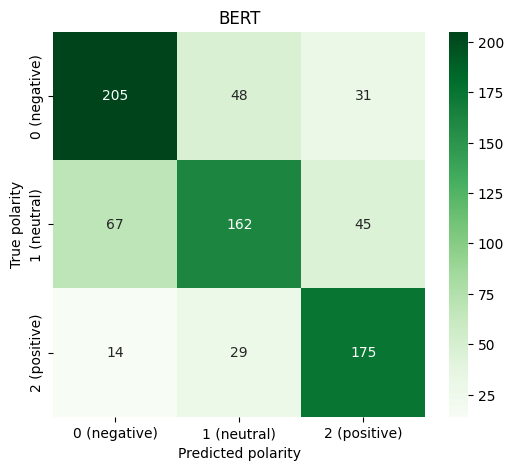

In [ ]:
total_acc, total_loss, test_f1, test_report, test_labels, test_preds = evaluate(finetuned_model, test_dataloader)

confusion_matrix = confusion_matrix(test_labels, test_preds, labels=[0, 1, 2])

print("Classification Report:\n", test_report)
print("Confusion Matrix:\n", confusion_matrix)


if confusion_matrix.shape == (2, 2):
    tn, fp, fn, tp = confusion_matrix.ravel()
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
else:
    print("Multi-class detected (3 classes). Unpacking binary rates is not applicable.")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['0 (negative)', '1 (neutral)', '2 (positive)'], 
            yticklabels=['0 (negative)', '1 (neutral)', '2 (positive)'])

plt.xlabel("Predicted polarity")
plt.ylabel("True polarity")
plt.title("BERT")
plt.show()